## Лабораторна робота №4
### Морфологічні операції
Виконав студент групи ФІ-31 Дремко Олександр

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Функції

Морфологічна ерозія

In [2]:
def erosion(binary_image, kernel):
    # Отримання розмірів ядра
    kernel_h, kernel_w = kernel.shape
    
    # Розрахунок кількості доповнень для зображення
    pad_h, pad_w = kernel_h // 2, kernel_w // 2
    
    # Додавання полів (заповнених нулями) до бінарного зображення
    padded_image = np.pad(binary_image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Порожній масив такого ж розміру, як оригінальне зображення, для збереження результату
    eroded_image = np.zeros_like(binary_image)

    # Перебір кожного пікселя оригінального зображення
    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):
            
            # Вибір регіону під ядро
            region = padded_image[i:i + kernel_h, j:j + kernel_w]
            
             # Перевірка, чи є хоча б один піксель у регіоні ядра, що дорівнює 1
            if np.any(region[kernel == 1] == 1):
                eroded_image[i, j] = 1  # Встановлення значення 1, якщо умова виконана
    return eroded_image

Морфологічне нарощування

In [3]:
def dilation(binary_image, kernel):
    # Отримання розмірів ядра
    kernel_h, kernel_w = kernel.shape
    
    # Розрахунок кількості доповнень для зображення
    pad_h, pad_w = kernel_h // 2, kernel_w // 2
    
    # Додавання полів (заповнених нулями) до бінарного зображення
    padded_image = np.pad(binary_image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    # Порожній масив такого ж розміру, як оригінальне зображення, для збереження результату
    dilated_image = np.zeros_like(binary_image)

    # Перебір кожного пікселя оригінального зображення
    for i in range(binary_image.shape[0]):
        for j in range(binary_image.shape[1]):
            
            # Вибір регіону під ядро
            region = padded_image[i:i + kernel_h, j:j + kernel_w]
            
            # Перевірка, чи всі пікселі в регіоні ядра дорівнюють 1
            if np.all(region[kernel == 1] == 1):
                dilated_image[i, j] = 1  # Встановлення значення 1, якщо умова виконана
    return dilated_image

Морфологічне розмикання

In [4]:
def opening(binary_image, kernel):
    # Ерозія
    eroded = erosion(binary_image, kernel)
    
    # Нарощування
    opened = dilation(eroded, kernel)
    return opened

Морфологічне замикання

In [5]:
def closing(binary_image, kernel):
    # Нарощування
    dilated = dilation(binary_image, kernel)
    
    # Ерозія
    closed = erosion(dilated, kernel)
    return closed

Границі

In [6]:
def boundary(binary_image, kernel):
    # Ерозія
    eroded = erosion(binary_image, kernel)
    
    # Обчислення різниці між оригінальним зображенням і результатом ерозії
    boundary_image = binary_image - eroded
    return boundary_image

Візуалізація

In [7]:
def show_image(image):
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

## Використаня

Підготовка зображення

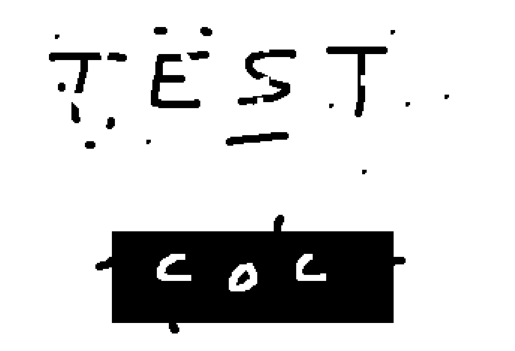

In [8]:
image_path = "example.png"

image = cv2.imread(image_path)

# Перетворення зображення з BGR у RGB (оскільки OpenCV завантажує в форматі BGR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Конвертація зображення в ч/б
grayscale_image = np.dot(image[..., :3], [0.36, 0.53, 0.11]).astype(np.float32)

# Перетворення у бінарне зображення
binary_image = (grayscale_image > 127).astype(np.uint8)

show_image(binary_image)

Налаштування ядра

In [9]:
kernel = np.ones((3, 3), dtype=np.uint8)

1. Erosion (ерозiя)

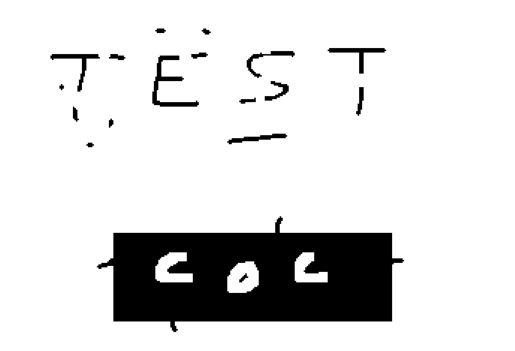

In [10]:
eroded_image = erosion(binary_image, kernel)
show_image(eroded_image)

2. Dilation (нарощування)

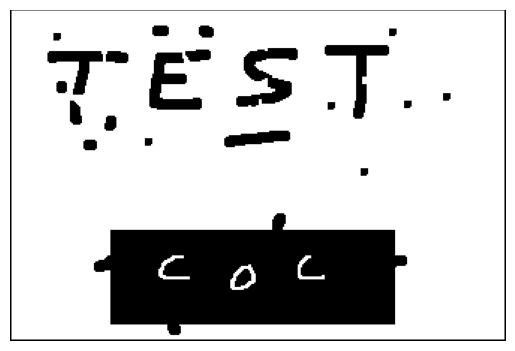

In [11]:
dilated_image = dilation(binary_image, kernel)
show_image(dilated_image)

3. Opening (розмикання)

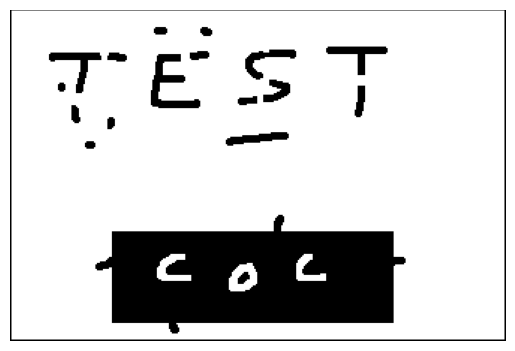

In [12]:
opened_image = opening(binary_image, kernel)
show_image(opened_image)

4. Closing (замикання)

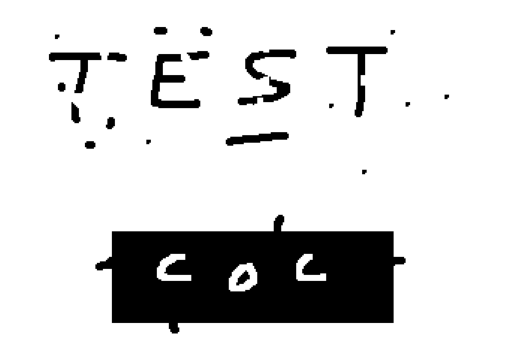

In [13]:
closed_image = closing(binary_image, kernel)
show_image(closed_image)

5. Границi

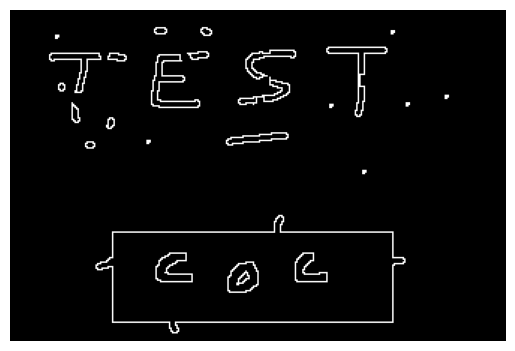

In [14]:
boundary_image = boundary(binary_image, kernel)
show_image(boundary_image)